## Setup Libraries

In [1]:
!pip install -q pytabkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 7.1 MB/s eta 0:00:00


In [2]:
import random
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from colorama import Fore, Style
from importlib.metadata import version
from time import time

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer, TargetEncoder
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import torch
import pytabkit
from pytabkit import RealMLP_TD_Classifier

warnings.filterwarnings('ignore')
print("PyTorch  version:", torch.__version__)
print("PyTabKit version:", version("pytabkit"))

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
seed_everything(42)

PyTorch  version: 2.11.0+cu128
PyTabKit version: 1.7.3


## Load Data

In [3]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e10/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = "/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/"
    orig = pd.read_csv(ORIG_PATH+"data.csv")
elif PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    PATH   = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e10 | Airline Satisfaction/_airline_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train  = pd.read_csv(PATH+"train.csv")
    test   = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"data.csv")

# if torch.cuda.is_available():
#     submit = cudf.DataFrame(submit)
#     train = cudf.DataFrame(train)
#     test = cudf.DataFrame(test)
#     orig = cudf.DataFrame(orig)

## =================================================================================

for (name, df) in {"Train": train, "Test": test, 'Orig': orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nFrame type: {type(train)}")

Train shape: (699635, 23)
Test shape: (299844, 22)
Orig shape: (129880, 22)

Frame type: <class 'pandas.core.frame.DataFrame'>


## Preprocess Features

In [4]:
# %%time
# ID = 'id'
# TARGET = 'Will_Buy_EV'
# train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
# orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
# X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
# y = train[TARGET]
# X_test = test.drop([ID], axis=1); test_id = test[ID]
# del train, test
# print("X      init shape:", X.shape)
# print("X_test init shape:", X_test.shape, "\n")

# cat_cols = X.select_dtypes(include=['object']).columns.tolist()
# num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
# print("init len(cat_cols):", len(cat_cols))
# print("init len(num_cols):", len(num_cols), "\n")

# category_map = {}
# important_combos = [
#     ('Annual_Income_USD', 'Range_Anxiety_Level'),
#     ('Age', 'Range_Anxiety_Level'),
#     ('Annual_Income_USD', 'Income_/_100_floor_'),
# ]
# def feature_engineering(df, fit=False):
#     # Fill NaNs
#     for col in cat_cols:
#         df[col] = df[col].fillna("missing")
#     for col in num_cols:
#         df[col] = df[col].fillna(0.0)

#     # Categorize string cats
#     for col in cat_cols:
#         if fit:
#             codes, uniques = df[col].factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = df[col].map(code_map).fillna(-1).astype('int32')
#         df[col] = codes
#         df[col] = df[col].astype('category')

#     # Arithmetic interaction
#     df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
#     df['Income_/_100_floor_']  = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
#     df['Income_/_1000_floor_']  = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
#     df['Income_/_10000_floor_']  = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
#     df['Daily_km_/_5_floor_']  = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')

#     # Categorize numericals
#     for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
#         cat_name = f"{col}_cat_"
#         if fit:
#             codes, uniques = np.floor(df[col]).factorize()
#             category_map[col] = uniques
#         else:
#             uniques = category_map[col]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
#         df[cat_name] = codes
#         df[cat_name] = df[cat_name].astype('category')

#     # Digit extraction
#     for col in ['Daily_Commute_km']:
#         decimal_name = f"_{col}_decimal"
#         df[decimal_name] = (df[col] % 1).round(2).astype('float32')
#     df['Annual_Income_USD_is_multiple_10_'] = (np.floor(df['Annual_Income_USD']) % 10 == 0).astype('category')

#     # Target encoding from orig
#     for col in ['Annual_Income_USD']:
#         orig_enc_name = f"_{col}_mean_target_orig"
#         df[orig_enc_name] = (
#             df[col]
#             .map(orig.groupby(col)[TARGET].mean())
#             .fillna(orig[TARGET].mean())
#             .astype('float32')
#         )

#     # Count encoding
#     for col in ['Annual_Income_USD']:
#         count_name = f"_{col}_count"
#         if fit:
#             count_map = df[col].value_counts()
#             category_map[count_name] = count_map
#         else:
#             count_map = category_map[count_name]
#         df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

#     # Discretize numericals
#     bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
#     for col, bins_list in bin_config.items():
#         for n_bins in bins_list:
#             for strategy in ['quantile']:
#                 bin_name = f"{col}_{n_bins}_{strategy}_bin_"
#                 if fit:
#                     kb = KBinsDiscretizer(
#                         n_bins=n_bins,
#                         encode='ordinal',
#                         strategy=strategy,
#                         subsample=None
#                     )
#                     binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
#                     category_map[bin_name] = kb
#                 else:
#                     kb = category_map[bin_name]
#                     binned = kb.transform(df[[col]]).ravel().astype('int32')
#                 df[bin_name] = binned
#                 df[bin_name] = df[bin_name].astype('category')

#     # Create interaction categories
#     combo_names = []
#     for cols in important_combos:
#         combo_name = '_'.join(cols) + '_'
#         combo_names.append(combo_name)
#         combo_series = df[cols[0]].astype(str)
#         for col in cols[1:]:
#             combo_series = combo_series + '_' + df[col].astype(str)
#         if fit:
#             codes, uniques = pd.factorize(combo_series, sort=False)
#             category_map[combo_name] = uniques
#         else:
#             uniques = category_map[combo_name]
#             code_map = {cat: i for i, cat in enumerate(uniques)}
#             codes = combo_series.map(code_map).fillna(-1).astype('int32')
#         df[combo_name] = codes
#         df[combo_name] = df[combo_name].astype('category')   

#     new_cat_cols = [col for col in df.columns if col.endswith('_')]
#     new_num_cols = [col for col in df.columns if col.startswith('_')]
#     return df, new_cat_cols, new_num_cols, combo_names

# X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
# X_test, _, _, _ = feature_engineering(X_test, fit=False)
# cat_cols += new_cat_cols; num_cols += new_num_cols
# print("len(new_cat_cols):", len(new_cat_cols))
# print("len(new_num_cols):", len(new_num_cols), "\n")

# print("prep len(cat_cols):", len(cat_cols))
# print("prep len(num_cols):", len(num_cols), "\n")
# print("X      prep shape:", X.shape)
# print("X_test prep shape:", X_test.shape, "\n")

In [5]:
ID = 'id'
TARGET = 'satisfaction'
train[TARGET] = train[TARGET].map({False: 0, True: 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Class', 'Type of Travel', 'Gender'),
    ('Class', 'Type of Travel', 'Age'),
    ('Flight Distance', 'Departure/Arrival time convenient'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)
    
    # Categorize numericals
    for col in num_cols:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')

    # Count encoding
    for col in cat_cols + ['Leg room service']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].map(count_map).fillna(0).astype('int32')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category') 

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X      init shape: (699635, 21)
X_test init shape: (299844, 21) 

init len(cat_cols): 4
init len(num_cols): 17 

len(new_cat_cols): 20
len(new_num_cols): 5 

prep len(cat_cols): 24
prep len(num_cols): 22 

X      prep shape: (699635, 46)
X_test prep shape: (299844, 46) 



## Config

In [6]:
class CFG:
    FOLDS = 5
    SEED = 42
    TE = True

# params = {
#     'random_state': 42,
#     'verbosity': 2,
#     'val_metric_name': '1-auc_ovr',

#     'n_ens': 8,
#     'n_epochs': 5,
#     'batch_size': 256,
#     'use_early_stopping': False,
#     'early_stopping_additive_patience': 10,
#     'early_stopping_multiplicative_patience': 1,

#     'lr': 0.05,
#     'wd': 0.0236,
#     'sq_mom': 0.988,
#     'lr_sched': 'lin_cos_log_15',
#     'first_layer_lr_factor': 0.25,

#     'embedding_size': 5,
#     'max_one_hot_cat_size': 18,
#     'hidden_sizes': [512, 256, 128],
#     'act': 'silu',
#     'p_drop': 0.05,
#     'p_drop_sched': 'expm4t',

#     'plr_hidden_1': 16,
#     'plr_hidden_2': 8,
#     'plr_act_name': 'gelu',
#     'plr_lr_factor': 0.1151,
#     'plr_sigma': 2.33,

#     'ls_eps': 0.01,
#     'ls_eps_sched': 'sqrt_cos',

#     'add_front_scale': False,
#     'bias_init_mode': 'neg-uniform-dynamic-2',
#     'tfms': ['one_hot', 'median_center', 'robust_scale',
#              'smooth_clip', 'embedding', 'l2_normalize'],
# }

params = {
    'random_state': 42,
    'verbosity': 2,
    'val_metric_name': '1-auc_ovr',

    'n_ens': 8,
    'n_epochs': 3,
    'batch_size': 256,
    'use_early_stopping': False,
    'early_stopping_additive_patience': 10,
    'early_stopping_multiplicative_patience': 1,

    'lr': 0.053,
    'wd': 0.015,
    'sq_mom': 0.988,
    'lr_sched': 'flat_anneal',
    'wd_sched': 'cos_log_15',
    'first_layer_lr_factor': 0.25,

    'embedding_size': 5,
    'max_one_hot_cat_size': 1,
    'hidden_sizes': [512, 256, 128],
    'act': 'silu',
    'p_drop': 0.05,
    'p_drop_sched': 'pow5',

    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_act_name': 'gelu',
    'plr_lr_factor': 0.1151,
    'plr_sigma': 2.33,

    'ls_eps': 0.01,
    'ls_eps_sched': 'sqrt_cos',

    'add_front_scale': False,
    'bias_init_mode': 'neg-uniform-dynamic-2',
    'tfms': ['one_hot', 'median_center', 'robust_scale',
             'smooth_clip', 'embedding', 'l2_normalize'],
}

params

{'random_state': 42,
 'verbosity': 2,
 'val_metric_name': '1-auc_ovr',
 'n_ens': 8,
 'n_epochs': 3,
 'batch_size': 256,
 'use_early_stopping': False,
 'early_stopping_additive_patience': 10,
 'early_stopping_multiplicative_patience': 1,
 'lr': 0.053,
 'wd': 0.015,
 'sq_mom': 0.988,
 'lr_sched': 'flat_anneal',
 'wd_sched': 'cos_log_15',
 'first_layer_lr_factor': 0.25,
 'embedding_size': 5,
 'max_one_hot_cat_size': 1,
 'hidden_sizes': [512, 256, 128],
 'act': 'silu',
 'p_drop': 0.05,
 'p_drop_sched': 'pow5',
 'plr_hidden_1': 16,
 'plr_hidden_2': 8,
 'plr_act_name': 'gelu',
 'plr_lr_factor': 0.1151,
 'plr_sigma': 2.33,
 'ls_eps': 0.01,
 'ls_eps_sched': 'sqrt_cos',
 'add_front_scale': False,
 'bias_init_mode': 'neg-uniform-dynamic-2',
 'tfms': ['one_hot',
  'median_center',
  'robust_scale',
  'smooth_clip',
  'embedding',
  'l2_normalize']}

## Train K-Fold

In [7]:
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

model_name = 'pytab_REALMLP'
print(f"\n🚀 Training {model_name} with {FOLDS } Folds...")

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

t0 = time()
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr = X.iloc[tr_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]
    X_tst = X_test.copy()  

    # Target encoding
    if CFG.TE:
        te_cols = combo_names
        TE = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
        tr_enc = TE.fit_transform(X_tr[te_cols], y_tr)
        va_enc = TE.transform(X_val[te_cols])
        ts_enc = TE.transform(X_tst[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_tr[te_names]  = tr_enc
        X_val[te_names] = va_enc
        X_tst[te_names] = ts_enc

        combos_to_drop = ['Class_Type of Travel_Age_', 'Flight Distance_Departure/Arrival time convenient_']
        X_tr = X_tr.drop(columns=combos_to_drop)
        X_val = X_val.drop(columns=combos_to_drop)
        X_tst = X_tst.drop(columns=combos_to_drop)

    if fold == 1: print("len(FEATURES):", len(X_tr.columns.tolist()), "\n")
    print("#"*16)
    print(f"### Fold {fold}/{FOLDS} ...")
    print("#"*16)

    model = RealMLP_TD_Classifier(**params)
    
    seeder = 42 #+ (fold-1)
    model.random_state = seeder

    model.fit(X_tr, y_tr, X_val, y_val, cat_col_names=cat_cols) #

    val_preds = model.predict_proba(X_val)[:, 1]
    fold_test_preds = model.predict_proba(X_tst)[:, 1]

    oof_preds[val_idx] = val_preds
    test_preds += fold_test_preds / FOLDS

    fold_score = roc_auc_score(y_val, val_preds)
    fold_scores.append(fold_score)
    print(f"seed={seeder}", end=" | ")
    print(f"{Fore.GREEN}{Style.BRIGHT}Fold {fold} | AUC: {fold_score:.6f}{Style.RESET_ALL}\n")
    torch.cuda.empty_cache()

## -- CV results --
fold_results = {}

print(f"\n{'='*50}")
print(f"{FOLDS}-FOLD CV: {model_name} | {X_tr.shape}")
print(f"{'='*50}")
for i, s in enumerate(fold_scores, 1):
    print(f" • Fold {i} AUC: {s:.6f}")
    fold_results[f'fold_{i}'] = s

## -- Final out-of-fold score --
oof_auc = np.round(roc_auc_score(y, oof_preds), 6)
avg_auc = np.round(np.mean(fold_scores), 6)
std_auc = np.round(np.std(fold_scores), 6)

print("-------------------------------------------------|")
print(f"OOF score: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG score: {Fore.BLUE}{Style.BRIGHT}{avg_auc} ± {std_auc}{Style.RESET_ALL}")
print("-------------------------------------------------|")
print(f"{((time()-t0)/60):.2f} mins\n")


🚀 Training pytab_REALMLP with 5 Folds...
len(FEATURES): 47 

################
### Fold 1/5 ...
################
Columns classified as continuous: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', '_Gender_count', '_Customer Type_count', '_Type of Travel_count', '_Class_count', '_Leg room service_count', '_Class_Type of Travel_Gender_TE', '_Class_Type of Travel_Age_TE', '_Flight Distance_Departure/Arrival time convenient_TE']
Columns classified as categorical: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Age_cat_', 'Flight Distance_cat_', 'Inflight wifi service_cat_', 'Departure/Arrival time convenient_cat_', 'Ease of Online booking_cat_', 'Gate location_cat_', 'Food 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/3: val 1-auc_ovr = 0.039524
Epoch 2/3: val 1-auc_ovr = 0.038963
Epoch 3/3: val 1-auc_ovr = 0.038492


`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


seed=42 | Fold 1 | AUC: 0.961508

################
### Fold 2/5 ...
################
Columns classified as continuous: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', '_Gender_count', '_Customer Type_count', '_Type of Travel_count', '_Class_count', '_Leg room service_count', '_Class_Type of Travel_Gender_TE', '_Class_Type of Travel_Age_TE', '_Flight Distance_Departure/Arrival time convenient_TE']
Columns classified as categorical: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Age_cat_', 'Flight Distance_cat_', 'Inflight wifi service_cat_', 'Departure/Arrival time convenient_cat_', 'Ease of Online booking_cat_', 'Gate location_cat_', 'Food and drink_cat_', 'Online boa

...

seed=42 | Fold 4 | AUC: 0.961295

################
### Fold 5/5 ...
################
Columns classified as continuous: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', '_Gender_count', '_Customer Type_count', '_Type of Travel_count', '_Class_count', '_Leg room service_count', '_Class_Type of Travel_Gender_TE', '_Class_Type of Travel_Age_TE', '_Flight Distance_Departure/Arrival time convenient_TE']
Columns classified as categorical: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Age_cat_', 'Flight Distance_cat_', 'Inflight wifi service_cat_', 'Departure/Arrival time convenient_cat_', 'Ease of Online booking_cat_', 'Gate location_cat_', 'Food and drink_cat_', 'Online boa

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/3: val 1-auc_ovr = 0.039854
Epoch 2/3: val 1-auc_ovr = 0.039429
Epoch 3/3: val 1-auc_ovr = 0.038929


`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


seed=42 | Fold 5 | AUC: 0.961071


5-FOLD CV: pytab_REALMLP | (559708, 47)
 • Fold 1 AUC: 0.961508
 • Fold 2 AUC: 0.960242
 • Fold 3 AUC: 0.961959
 • Fold 4 AUC: 0.961295
 • Fold 5 AUC: 0.961071
-------------------------------------------------|
OOF score: 0.96121
AVG score: 0.961215 ± 0.000568
-------------------------------------------------|
9.25 mins



## Evaluation and Submission

In [8]:
n = f"{model_name}_{avg_auc}"

print("\n" + "="*28)
print(f"AUC: {Fore.BLUE}{Style.BRIGHT}{n}{Style.RESET_ALL}")
print("="*28)

fold_df = pd.DataFrame.from_dict(fold_results, orient='index', columns=['score'])
print(fold_df.to_string())


AUC: pytab_REALMLP_0.961215
           score
fold_1  0.961508
fold_2  0.960242
fold_3  0.961959
fold_4  0.961295
fold_5  0.961071


In [9]:
np.save(f"oof_{n}.npy", oof_preds)
np.save(f"test_{n}.npy", test_preds)

submit[TARGET] = test_preds
submit.to_csv(f"submit_{n}.csv", index=False)

submit

,id,satisfaction
0,699635,0.230802
1,699636,0.852023
2,699637,0.932991
3,699638,0.066926
4,699639,0.052645
...,...,...
299839,999474,0.030211
299840,999475,0.038334
299841,999476,0.195547
299842,999477,0.019651


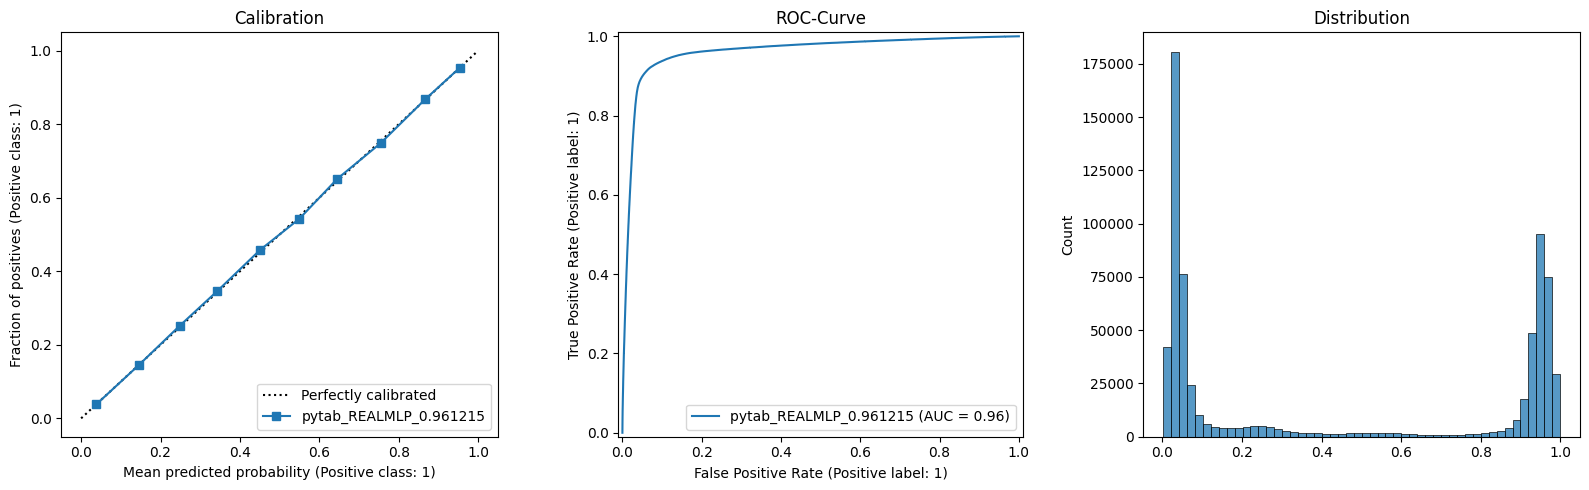

In [10]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5)) 
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=n, ax=axs[0])
axs[0].set_title(f"Calibration")

RocCurveDisplay.from_predictions(y, oof_preds, name=n, ax=axs[1])
axs[1].set_title(f"ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"Distribution")

plt.tight_layout()
plt.show()

print()

In [11]:
# !rm -r /kaggle/working